In [ ]:
import os
import sys

import pandas as pd
from typing import Sequence

MANUSCRIPT_DIR = os.path.abspath(os.getcwd())
if os.path.basename(MANUSCRIPT_DIR) != "manuscript":
    MANUSCRIPT_DIR = os.path.abspath(os.path.join(os.getcwd(), "src", "manuscript"))

DATA_DIR = os.path.join(MANUSCRIPT_DIR, "data")

if MANUSCRIPT_DIR not in sys.path:
    sys.path.insert(0, MANUSCRIPT_DIR)

def data_path(filename):
    return os.path.join(DATA_DIR, filename)

# Figure 2 and Supplementary Figures


In [ ]:
from fig2.utils import (
    build_cross_target_payloads,
    build_labeled_fasta_payloads,
    build_method_payloads,
    plot_auc_bars,
    plot_auc_heatmap,
)

from fig2.decoy_classifier import PeptidePairInput, run_decoy_classifier

FIG2_DIR = os.path.join(MANUSCRIPT_DIR, "fig2")

OUTPUT_DIR = os.path.join(FIG2_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)


def output_path(filename):
    return os.path.join(OUTPUT_DIR, filename)

In [3]:
def run_classifier_experiment(
    payloads: Sequence[dict[str, object]],
    out_csv: str | None = None,
    cross_validation_fold: int = 5,
):
    result = run_decoy_classifier(
        pairs=[PeptidePairInput(**payload) for payload in payloads],
        cross_validation_fold=cross_validation_fold,
        out_stats_csv=out_csv,
    )
    return result, pd.DataFrame(result.stats_rows)


def run_bar_figure(payloads, stem, title, ylim, label_map=None):
    _, stats = run_classifier_experiment(payloads=payloads, out_csv=output_path(f"{stem}.csv"))
    plot_auc_bars(
        stats,
        out_pdf=output_path(f"{stem}.pdf"),
        title=title,
        ylim=ylim,
        label_map=label_map,
    )
    return stats


def run_heatmap_figure(payloads, stem, rows, columns, title):
    _, stats = run_classifier_experiment(payloads=payloads, out_csv=output_path(f"{stem}.csv"))
    plot_auc_heatmap(
        stats,
        out_pdf=output_path(f"{stem}.pdf"),
        rows=rows,
        columns=columns,
        title=title,
    )
    return stats


def build_esm2_fastas(model_sizes, variants):
    return [
        (
            f"{model_label}.{variant_name}",
            data_path(f"human_and_crap.facebook_esm2_{model_token}_UR50D.best.{file_variant}.f32.fasta"),
        )
        for model_label, model_token in model_sizes
        for variant_name, file_variant in variants
    ]


## Figure 2 - Target-decoy separability test


Device: cuda

Pair target: 182135 class-A + 182135 class-B (total 364270)
Model parameters: total=1,679,233, trainable=1,679,233
Fold 1/5 | Train/val: 291416/72854
Fold 01 Epoch 01 | train loss 0.6943 acc 0.501 | val loss 0.6937 acc 0.501 auc 0.499
Fold 01 Epoch 02 | train loss 0.6934 acc 0.502 | val loss 0.6935 acc 0.500 auc 0.501
Fold 01 Epoch 03 | train loss 0.6934 acc 0.502 | val loss 0.6935 acc 0.499 auc 0.497
Fold 2/5 | Train/val: 291416/72854
Fold 02 Epoch 01 | train loss 0.6943 acc 0.499 | val loss 0.6934 acc 0.502 auc 0.504
Fold 02 Epoch 02 | train loss 0.6935 acc 0.502 | val loss 0.6934 acc 0.500 auc 0.501
Fold 02 Epoch 03 | train loss 0.6933 acc 0.502 | val loss 0.6932 acc 0.506 auc 0.506
Fold 3/5 | Train/val: 291416/72854
Fold 03 Epoch 01 | train loss 0.6944 acc 0.499 | val loss 0.6936 acc 0.499 auc 0.498
Fold 03 Epoch 02 | train loss 0.6934 acc 0.503 | val loss 0.6937 acc 0.500 auc 0.498
Fold 03 Epoch 03 | train loss 0.6934 acc 0.502 | val loss 0.6935 acc 0.500 auc 0.498
F

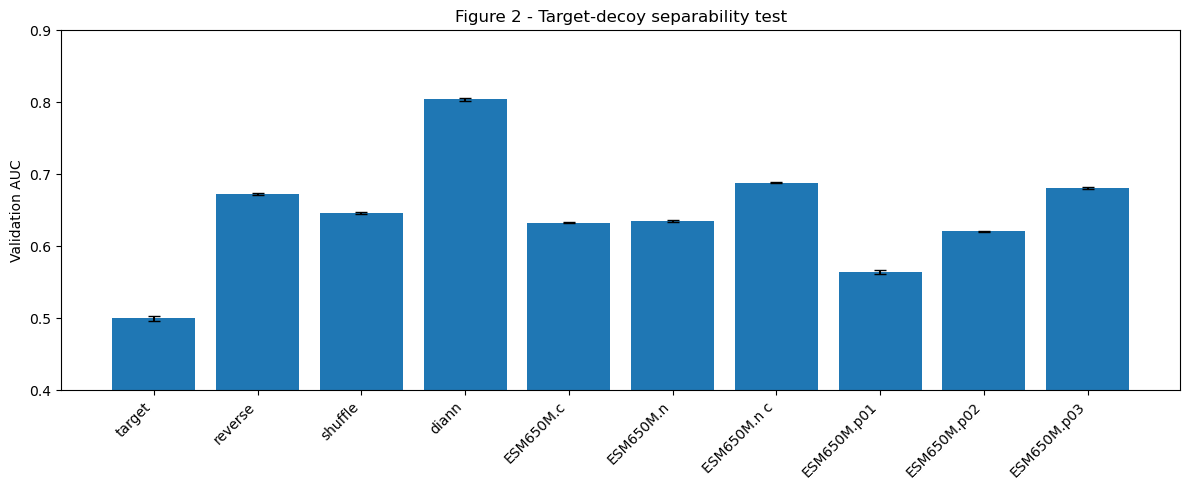

,class_a,class_b,auc_mean,auc_std,experiment
0,182135,182135,0.499934,0.003305,target
1,364254,364254,0.673007,0.001589,reverse
2,364250,364250,0.645913,0.001434,shuffle
3,363834,363834,0.803926,0.002022,diann
4,360710,360710,0.632786,0.000850,ESM650M.c
5,361847,361847,0.634475,0.001390,ESM650M.n
6,361706,361706,0.688072,0.000722,ESM650M.n_c
7,362485,362485,0.563896,0.002792,ESM650M.p01
8,362669,362669,0.620600,0.001220,ESM650M.p02
9,362703,362703,0.681305,0.001312,ESM650M.p03


In [4]:
STANDARD_TARGET_FASTA = data_path("UP000005640_9606.fasta")
STANDARD_DECOY_METHODS = [("reverse", "reverse"), ("shuffle", "shuffle"), ("diann", "diann")]
STANDARD_ESM_FASTAS = [
    ("ESM650M.c", data_path("human_and_crap_facebook_esm2_t33_650M_UR50D_best_c_term_f32.fasta")),
    ("ESM650M.n", data_path("human_and_crap_facebook_esm2_t33_650M_UR50D_best_n_term_f32.fasta")),
    ("ESM650M.n_c", data_path("human_and_crap_facebook_esm2_t33_650M_UR50D_best_n_c_term_f32.fasta")),
    ("ESM650M.p01", data_path("human_and_crap.facebook_esm2_t33_650M_UR50D.best.p01.f32.fasta")),
    ("ESM650M.p02", data_path("human_and_crap.facebook_esm2_t33_650M_UR50D.best.p02.f32.fasta")),
    ("ESM650M.p03", data_path("human_and_crap.facebook_esm2_t33_650M_UR50D.best.p03.f32.fasta")),
]

figure2_stats = run_bar_figure(
    payloads=build_method_payloads(STANDARD_TARGET_FASTA, STANDARD_DECOY_METHODS)
    + build_labeled_fasta_payloads(STANDARD_ESM_FASTAS),
    stem="figure2",
    title="Figure 2 - Target-decoy separability test",
    ylim=(0.4, 0.9),
)
figure2_stats


## Figure S1B - Multi-species comparison


Device: cuda

Pair target: 182135 class-A + 182135 class-B (total 364270)
Model parameters: total=1,679,233, trainable=1,679,233
Fold 1/5 | Train/val: 291416/72854
Fold 01 Epoch 01 | train loss 0.6943 acc 0.501 | val loss 0.6937 acc 0.501 auc 0.499
Fold 01 Epoch 02 | train loss 0.6934 acc 0.502 | val loss 0.6935 acc 0.500 auc 0.501
Fold 01 Epoch 03 | train loss 0.6934 acc 0.502 | val loss 0.6935 acc 0.499 auc 0.497
Fold 2/5 | Train/val: 291416/72854
Fold 02 Epoch 01 | train loss 0.6943 acc 0.499 | val loss 0.6934 acc 0.502 auc 0.504
Fold 02 Epoch 02 | train loss 0.6935 acc 0.502 | val loss 0.6934 acc 0.500 auc 0.501
Fold 02 Epoch 03 | train loss 0.6933 acc 0.502 | val loss 0.6932 acc 0.506 auc 0.506
Fold 3/5 | Train/val: 291416/72854
Fold 03 Epoch 01 | train loss 0.6944 acc 0.499 | val loss 0.6936 acc 0.499 auc 0.498
Fold 03 Epoch 02 | train loss 0.6934 acc 0.503 | val loss 0.6937 acc 0.500 auc 0.498
Fold 03 Epoch 03 | train loss 0.6934 acc 0.502 | val loss 0.6935 acc 0.500 auc 0.498
F

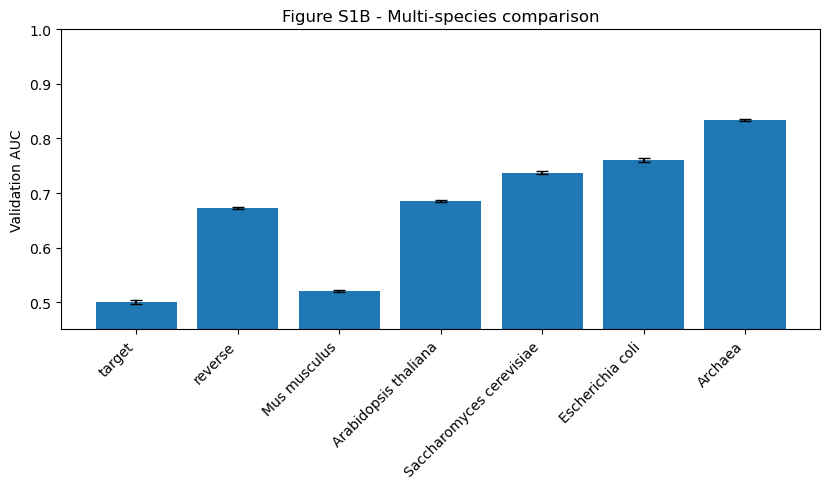

,class_a,class_b,auc_mean,auc_std,experiment
0,182135,182135,0.499934,0.003305,target
1,364254,364254,0.673007,0.001589,reverse
2,215897,215897,0.519939,0.001698,Mus_musculus
3,244472,244472,0.685331,0.001263,Arabidopsis_thaliana
4,94723,94723,0.737472,0.002242,Saccharomyces_cerevisiae
5,46515,46515,0.761012,0.003785,Escherichia_coli
6,163100,163100,0.833009,0.001846,archaea_uniprot


In [5]:
SPECIES_FASTAS = [
    ("Mus_musculus", data_path("UP000000589_10090.fasta")),
    ("Arabidopsis_thaliana", data_path("UP000006548_3702.fasta")),
    ("Saccharomyces_cerevisiae", data_path("UP000002311_559292.fasta")),
    ("Escherichia_coli", data_path("UP000000625_83333.fasta")),
    ("archaea_uniprot", data_path("archaea_uniprot.fasta")),
]
SPECIES_LABELS = {
    "target": "target",
    "reverse": "reverse",
    "Mus_musculus": "Mus musculus",
    "Arabidopsis_thaliana": "Arabidopsis thaliana",
    "Saccharomyces_cerevisiae": "Saccharomyces cerevisiae",
    "Escherichia_coli": "Escherichia coli",
    "archaea_uniprot": "Archaea",
}

figure_s1b_stats = run_bar_figure(
    payloads=build_cross_target_payloads(
        reference_fasta=STANDARD_TARGET_FASTA,
        comparison_fastas=SPECIES_FASTAS,
        decoy_methods=[("reverse", "reverse")],
    ),
    stem="figure_s1b",
    title="Figure S1B - Multi-species comparison",
    ylim=(0.45, 1.0),
    label_map=SPECIES_LABELS,
)
figure_s1b_stats


## Figure S1C - ESM2 generation modes and model sizes


Device: cuda

Pair 8M.c_term: 360945 class-A + 360945 class-B (total 721890)
Model parameters: total=1,679,233, trainable=1,679,233
Fold 1/5 | Train/val: 577512/144378
Fold 01 Epoch 01 | train loss 0.6166 acc 0.664 | val loss 0.6089 acc 0.673 auc 0.724
Fold 01 Epoch 02 | train loss 0.6083 acc 0.672 | val loss 0.6067 acc 0.674 auc 0.726
Fold 01 Epoch 03 | train loss 0.6052 acc 0.675 | val loss 0.6062 acc 0.675 auc 0.726
Fold 2/5 | Train/val: 577512/144378
Fold 02 Epoch 01 | train loss 0.6164 acc 0.664 | val loss 0.6092 acc 0.671 auc 0.723
Fold 02 Epoch 02 | train loss 0.6083 acc 0.673 | val loss 0.6063 acc 0.674 auc 0.726
Fold 02 Epoch 03 | train loss 0.6054 acc 0.675 | val loss 0.6054 acc 0.675 auc 0.728
Fold 3/5 | Train/val: 577512/144378
Fold 03 Epoch 01 | train loss 0.6163 acc 0.665 | val loss 0.6083 acc 0.673 auc 0.724
Fold 03 Epoch 02 | train loss 0.6086 acc 0.672 | val loss 0.6052 acc 0.675 auc 0.728
Fold 03 Epoch 03 | train loss 0.6057 acc 0.675 | val loss 0.6047 acc 0.676 auc 0

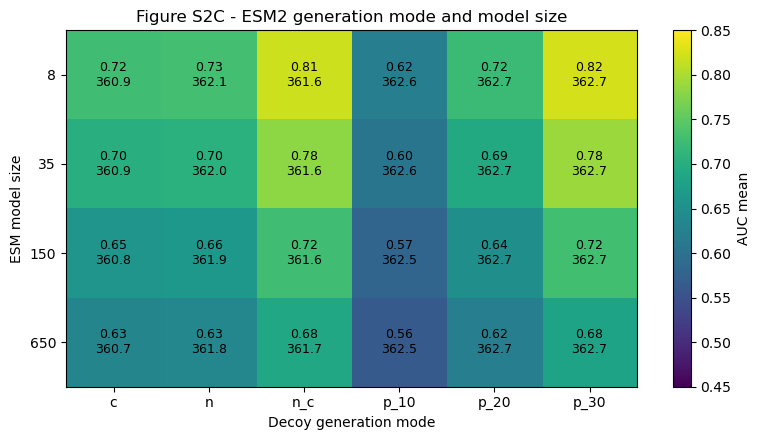

,class_a,class_b,auc_mean,auc_std,experiment
0,360945,360945,0.727428,0.001815,8M.c_term
1,362108,362108,0.731233,0.000945,8M.n_term
2,361610,361610,0.819234,0.000729,8M.n_c_term
3,362588,362588,0.620436,0.000550,8M.p01
4,362701,362701,0.722198,0.000422,8M.p02
5,362717,362717,0.823905,0.001506,8M.p03
6,360871,360871,0.702373,0.001763,35M.c_term
7,362048,362048,0.705055,0.001334,35M.n_term
8,361610,361610,0.782600,0.001531,35M.n_c_term
9,362568,362568,0.605565,0.002184,35M.p01


In [ ]:
ESM2_MODEL_SIZES = [("8M", "t6_8M"), ("35M", "t12_35M"), ("150M", "t30_150M"), ("650M", "t33_650M")]
ESM2_VARIANTS = [
    ("c_term", "c_term"),
    ("n_term", "n_term"),
    ("n_c_term", "n_c_term"),
    ("p01", "p01"),
    ("p02", "p02"),
    ("p03", "p03"),
]

figure_s1c_stats = run_heatmap_figure(
    payloads=build_labeled_fasta_payloads(build_esm2_fastas(ESM2_MODEL_SIZES, ESM2_VARIANTS)),
    stem="figure_s1c",
    rows=["8", "35", "150", "650"],
    columns=["c", "n", "n_c", "p_10", "p_20", "p_30"],
    title="Figure S1C - ESM2 generation mode and model size",
)
figure_s1c_stats
